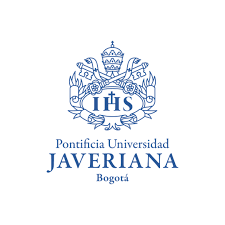
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Diego Zabala

Fecha de Inicio: 

Fecha actual: 

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**
El objetivo del proyecto es construir un flujo de análisis de calidad del agua en India, aplicando limpieza de datos, cálculo del índice WQI, visualización geográfica y modelos de Machine Learning/Keras para predecir la calidad del agua.
## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

# Levantamiento de variables de entorno pip


In [1]:
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd

In [2]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

### Levantamiento de sesión SPARK

In [3]:
configura = SparkConf()

configura.setAppName("Calidad_Agua_Zabala")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkContextoS = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")
SparkZabala = SparkSession.builder.config(conf=configura).getOrCreate()
SparkZabala

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 22:45:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


##**2.- Carga de Datos desde el HADOOP HDFS**

!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkS.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)

In [4]:
df00 = SparkZabala.read.format("csv").option("header","true").load("file:///Almacen/waterquality.csv")
df00 = df00.replace("NA", None)
df00.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## 3.- Análisis y Preparación de Datos

En esta sección se realiza la preparación inicial del dataset de calidad del agua. Primero se revisa la estructura de las columnas, luego se convierten las variables numéricas al tipo adecuado, se identifican valores faltantes reales y finalmente se aplica imputación con mediana.

Este orden es importante porque algunos valores faltantes estaban representados como texto, por ejemplo `"NA"`, y por tanto no podían ser detectados correctamente antes de realizar la conversión de tipos.

In [5]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

In [6]:
from pyspark.sql.types import FloatType
import pyspark.sql.functions as F

columnas_numericas = [
    'TEMP',
    'DO',
    'pH',
    'CONDUCTIVITY',
    'BOD',
    'NITRATE_N_NITRITE_N',
    'FECAL_COLIFORM',
    'TOTAL_COLIFORM'
]

for columna in columnas_numericas:
    df00 = df00.withColumn(columna, df00[columna].cast(FloatType()))

In [7]:
print("Valores nulos antes de la imputación:")

df00.select([
    F.count(
        F.when(
            F.isnan(F.col(c)) | F.col(c).isNull(),
            c
        )
    ).alias(c)
    for c in columnas_numericas
]).show()

Valores nulos antes de la imputación:


[Stage 2:>                                                          (0 + 1) / 1]

+----+---+---+------------+---+-------------------+--------------+--------------+
|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+----+---+---+------------+---+-------------------+--------------+--------------+
|   5|  2|  0|          30|  6|                  2|            82|            39|
+----+---+---+------------+---+-------------------+--------------+--------------+



In [8]:
###Revisar nulos reales e imputar con mediana

In [9]:
from pyspark.ml.feature import Imputer

imputer = Imputer(
    inputCols=columnas_numericas,
    outputCols=[c + "_imputed" for c in columnas_numericas]
).setStrategy("median")

df_imputed = imputer.fit(df00).transform(df00)

for c in columnas_numericas:
    df_imputed = df_imputed.drop(c).withColumnRenamed(c + "_imputed", c)

df00 = df_imputed

In [10]:
print("Valores nulos después de la imputación:")

df00.select([
    F.count(
        F.when(
            F.isnan(F.col(c)) | F.col(c).isNull(),
            c
        )
    ).alias(c)
    for c in columnas_numericas
]).show()

Valores nulos después de la imputación:


[Stage 9:>                                                          (0 + 1) / 1]

+----+---+---+------------+---+-------------------+--------------+--------------+
|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+----+---+---+------------+---+-------------------+--------------+--------------+
|   0|  0|  0|           0|  0|                  0|             0|             0|
+----+---+---+------------+---+-------------------+--------------+--------------+



### Eliminación de `TOTAL_COLIFORM`

Después de imputar los valores faltantes, se eliminó la columna `TOTAL_COLIFORM`. Esta decisión se tomó porque el cálculo del WQI utilizado en el cuaderno trabaja con `FECAL_COLIFORM` como variable microbiológica principal.

Además, eliminar esta columna reduce redundancia y simplifica el conjunto de variables que se utilizarán en las siguientes etapas de análisis y modelado.

In [11]:
df01 = df00.drop('TOTAL_COLIFORM')

**Se presenta las estadísticas de los datos a continuación:**

for valor in df00.columns:
  
  df00.describe([valor]).show()

In [12]:
df00.describe("STATION CODE").show()
df00.describe("LOCATIONS").show()
df00.describe("STATE").show()
df00.describe("TEMP").show()
df00.describe("DO").show()
df00.describe("pH").show()
df00.describe("CONDUCTIVITY").show()
df00.describe("BOD").show()
df00.describe("NITRATE_N_NITRITE_N").show()
df00.describe("FECAL_COLIFORM").show()
df00.describe("TOTAL_COLIFORM").show()


+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+



+-------+-----------------+
|summary|             TEMP|
+-------+-----------------+
|  count|              534|
|   mean|25.24382018150015|
| stddev|3.431892844981176|
|    min|             10.5|
|    max|             33.8|
+-------+-----------------+

+-------+------------------+
|summary|                DO|
+-------+------------------+
|  count|               534|
|   mean| 6.390973785313104|
| stddev|1.6199251165651511|
|    min|               0.0|
|    max|              16.3|
+-------+------------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean| 7.798127372613114|
| stddev|0.6499503850220179|
|    min|               6.3|
|    max|              14.7|
+-------+------------------+

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               534|
|   mean| 667.6179775280899|
| stddev|1720.2897864807028|
|    min|              39.0|
|    max|           

## **Visualización de los DATOS NULOS**

#Cantidad de Valores Nulos o Imposibles

In [13]:
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+





* ### Tratamiento de valores nulos

Después de convertir las variables numéricas a tipo `FloatType`, se identificaron valores nulos reales en varias columnas del dataset. Esto confirma que algunos valores faltantes estaban representados inicialmente como texto y no eran detectados correctamente.

Las columnas con mayor cantidad de valores nulos fueron `FECAL_COLIFORM`, `TOTAL_COLIFORM` y `CONDUCTIVITY`. Para evitar eliminar una cantidad considerable de registros y conservar la mayor cantidad de información posible, se decidió imputar los valores faltantes usando la mediana de cada variable. Esta estrategia es adecuada porque algunas variables ambientales presentan valores extremos, y la mediana es más robusta que la media frente a outliers.


* Se procede a Graficar cada una de las dimensiones
* #Se crea una vista para ser usada en las visualizaciones


In [14]:
df00.createOrReplaceTempView("df00_sql")
df01 = sparkS.sql('''Select * from df00_sql where TEMP is not null and
  
             DO is not null and
  
             pH is not null and
  
             CONDUCTIVITY is not null and
  
             BOD is not null and
  
             NITRATE_N_NITRITE_N is not null and
  
             FECAL_COLIFORM is not null''')

* #Se verifica la Cantidad de Valores Nulos o Imposibles
* df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

In [15]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **Tratamiento de datos**

* df00.dtypes
* ##Se procede a cambiar los tipos de datos


In [16]:
df00.dtypes

##Se procede a cambiar los tipos de datos


df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))

df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))

df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))

df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))

df00.dtypes


df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

- df01.createOrReplaceTempView("df01_sql")

- ###Se crea una consulta por cada parámetro DO
- do_parametro = sparkS.sql("Select DO from df01_sql")
- ##Se hace una consulta para crear el vector de la tabla por cada parámetro
- do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()
- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM 

## 4.- Análisis Exploratorio de Datos

En esta sección se realiza un análisis exploratorio de las variables fisicoquímicas y microbiológicas del agua. El objetivo es identificar la distribución de los datos, posibles valores extremos y relaciones entre variables antes de calcular el índice WQI y construir los modelos predictivos.

In [17]:
variables_eda = [
    'TEMP',
    'DO',
    'pH',
    'CONDUCTIVITY',
    'BOD',
    'NITRATE_N_NITRITE_N',
    'FECAL_COLIFORM'
]

df_eda = df01.select(variables_eda).toPandas()
df_eda.head()

,TEMP,DO,pH,CONDUCTIVITY,BOD,NITRATE_N_NITRITE_N,FECAL_COLIFORM
0,29.200001,6.4,8.1,735.0,3.4,2.00,3.0
1,24.500000,6.0,8.0,270.0,3.1,2.00,72.0
2,25.799999,5.5,7.8,355.0,4.2,9.00,59.0
3,24.799999,5.5,7.8,371.0,5.6,3.55,90.0
4,25.700001,5.7,7.9,294.0,3.2,2.69,45.0


Las estadísticas descriptivas permiten observar diferencias importantes en la escala de las variables. Mientras variables como `pH` y `DO` se mantienen en rangos relativamente pequeños, otras como `CONDUCTIVITY` y `FECAL_COLIFORM` presentan valores máximos muy altos. Esto indica la presencia de valores extremos y justifica el uso de la mediana en el tratamiento de nulos.

In [18]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
TEMP,534.0,25.243818,3.431893,10.5,23.299999,25.5,27.60,33.799999
DO,534.0,6.390974,1.619925,0.0,5.600000,6.7,7.40,16.299999
pH,534.0,7.798127,0.649950,6.3,7.500000,7.9,8.10,14.700000
CONDUCTIVITY,534.0,667.617981,1720.289795,39.0,273.000000,376.0,555.75,24062.000000
BOD,534.0,5.310112,8.457110,0.2,1.600000,2.7,5.00,75.599998
NITRATE_N_NITRITE_N,534.0,1.375655,2.799087,0.0,0.100000,0.6,1.70,45.500000
FECAL_COLIFORM,534.0,6311.694824,28365.017578,0.0,39.000000,400.0,1495.75,310417.000000


Los histogramas muestran que algunas variables no siguen una distribución simétrica. En particular, `CONDUCTIVITY`, `BOD` y `FECAL_COLIFORM` presentan concentración de datos en valores bajos, pero con algunos registros extremadamente altos. Este comportamiento es común en variables ambientales y puede afectar el desempeño de modelos sensibles a valores extremos.

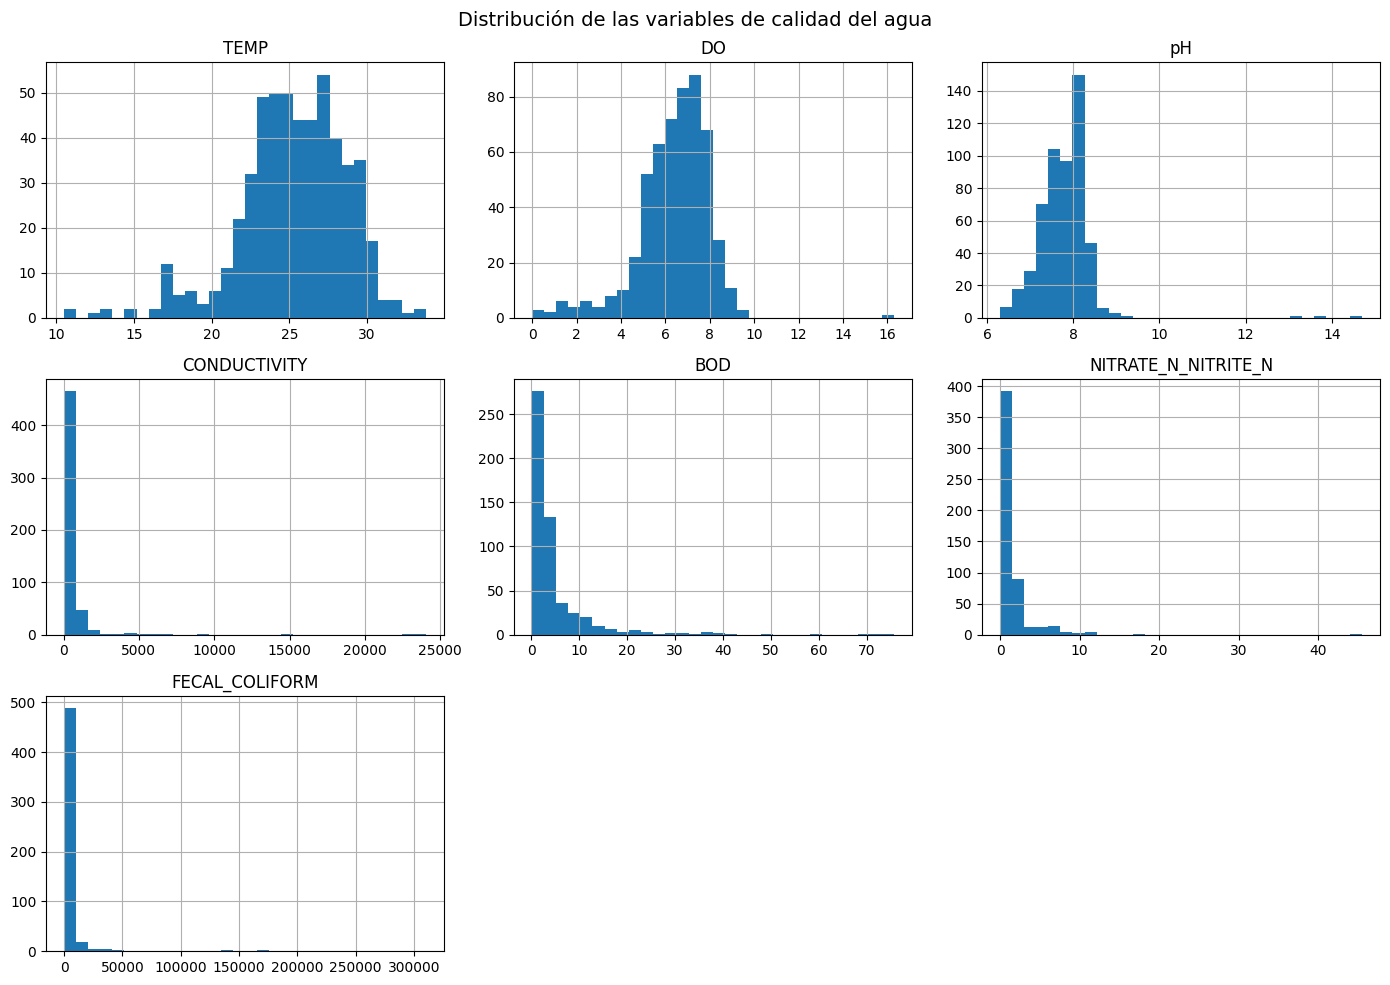

In [19]:
df_eda.hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribución de las variables de calidad del agua", fontsize=14)
plt.tight_layout()
plt.show()

Los boxplots permiten identificar visualmente la presencia de valores extremos. Se observa que variables como `FECAL_COLIFORM`, `CONDUCTIVITY` y `BOD` presentan outliers importantes. Estos valores no necesariamente deben eliminarse, ya que pueden representar eventos reales de contaminación; sin embargo, deben tenerse en cuenta al interpretar los resultados y entrenar modelos.

### Análisis de valores extremos

El boxplot general muestra que algunas variables presentan valores extremos muy altos, especialmente `FECAL_COLIFORM` y `CONDUCTIVITY`. Esto causa que las demás variables se visualicen comprimidas cerca de cero, debido a la diferencia de escalas.

Estos valores extremos no se eliminan automáticamente, ya que pueden representar condiciones reales de contaminación del agua. Sin embargo, deben tenerse en cuenta en la interpretación del análisis y en la construcción de los modelos predictivos.

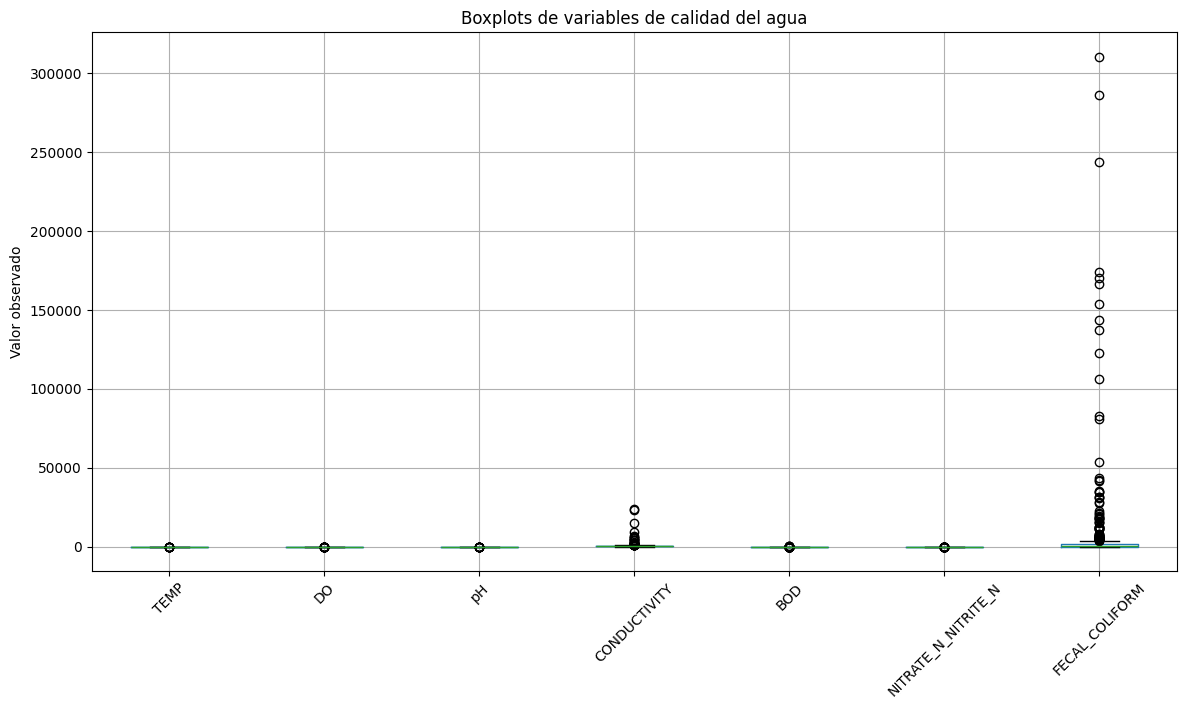

In [20]:
plt.figure(figsize=(14, 7))
df_eda.boxplot(rot=45)
plt.title("Boxplots de variables de calidad del agua")
plt.ylabel("Valor observado")
plt.grid(True)
plt.show()

### Boxplot con transformación logarítmica

Para mejorar la visualización de las variables con escalas muy diferentes, se aplicó la transformación `log1p`. Esta transformación reduce el efecto visual de valores extremos y permite comparar mejor la dispersión entre variables.

El gráfico transformado no reemplaza los datos originales, sino que se usa únicamente como apoyo visual para entender mejor la distribución de las variables.

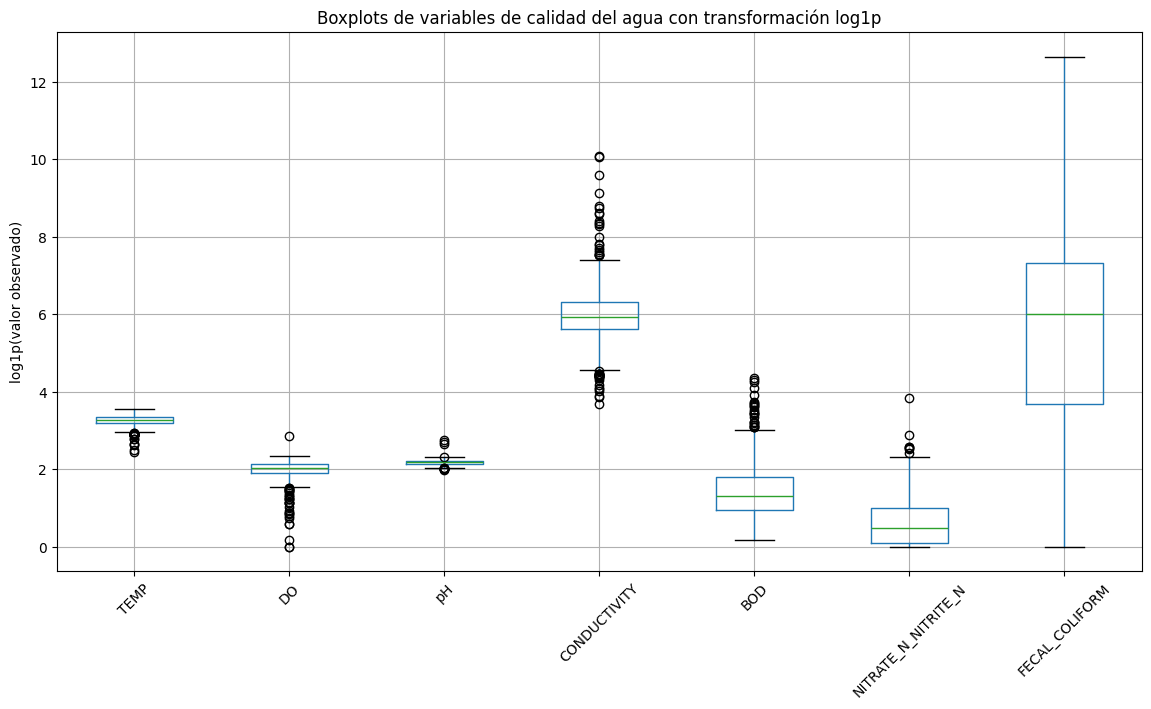

In [21]:
plt.figure(figsize=(14, 7))
df_eda_log = np.log1p(df_eda)

df_eda_log.boxplot(rot=45)
plt.title("Boxplots de variables de calidad del agua con transformación log1p")
plt.ylabel("log1p(valor observado)")
plt.grid(True)
plt.show()

La matriz de correlación permite analizar la relación lineal entre las variables. Esta revisión ayuda a identificar variables que pueden aportar información similar o relaciones relevantes para el modelo predictivo. Aunque la correlación no implica causalidad, sí permite comprender mejor la estructura inicial de los datos.

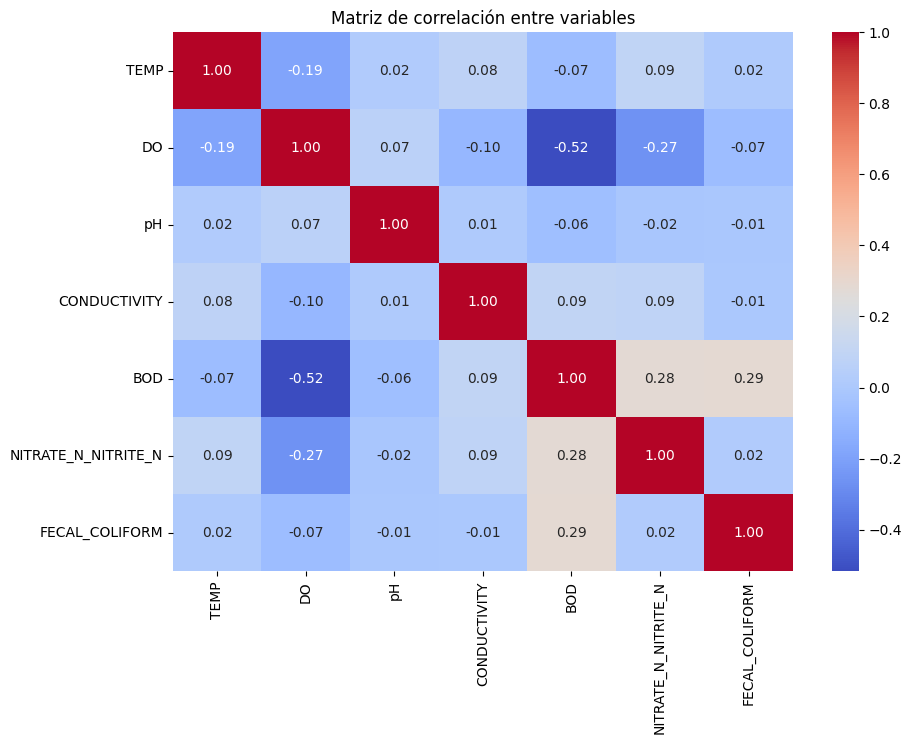

In [22]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_eda.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables")
plt.show()

In [23]:
df01.createOrReplaceTempView("df01_sql")

do_parametro = sparkS.sql("SELECT DO FROM df01_sql")
do_parametro = [fila["DO"] for fila in do_parametro.collect()]

ph_parametro = sparkS.sql("SELECT pH FROM df01_sql")
ph_parametro = [fila["pH"] for fila in ph_parametro.collect()]

conductivity_parametro = sparkS.sql("SELECT CONDUCTIVITY FROM df01_sql")
conductivity_parametro = [fila["CONDUCTIVITY"] for fila in conductivity_parametro.collect()]

bod_parametro = sparkS.sql("SELECT BOD FROM df01_sql")
bod_parametro = [fila["BOD"] for fila in bod_parametro.collect()]

nitrate_parametro = sparkS.sql("SELECT NITRATE_N_NITRITE_N FROM df01_sql")
nitrate_parametro = [fila["NITRATE_N_NITRITE_N"] for fila in nitrate_parametro.collect()]

fecal_parametro = sparkS.sql("SELECT FECAL_COLIFORM FROM df01_sql")
fecal_parametro = [fila["FECAL_COLIFORM"] for fila in fecal_parametro.collect()]

#print("DO:", do_parametro)
#print("pH:", ph_parametro)
#print("CONDUCTIVITY:", conductivity_parametro)
#print("BOD:", bod_parametro)
#print("NITRATE_N_NITRITE_N:", nitrate_parametro)
#print("FECAL_COLIFORM:", fecal_parametro)

* ###Grafica Los parámetros para conocer sus características: DO y PH


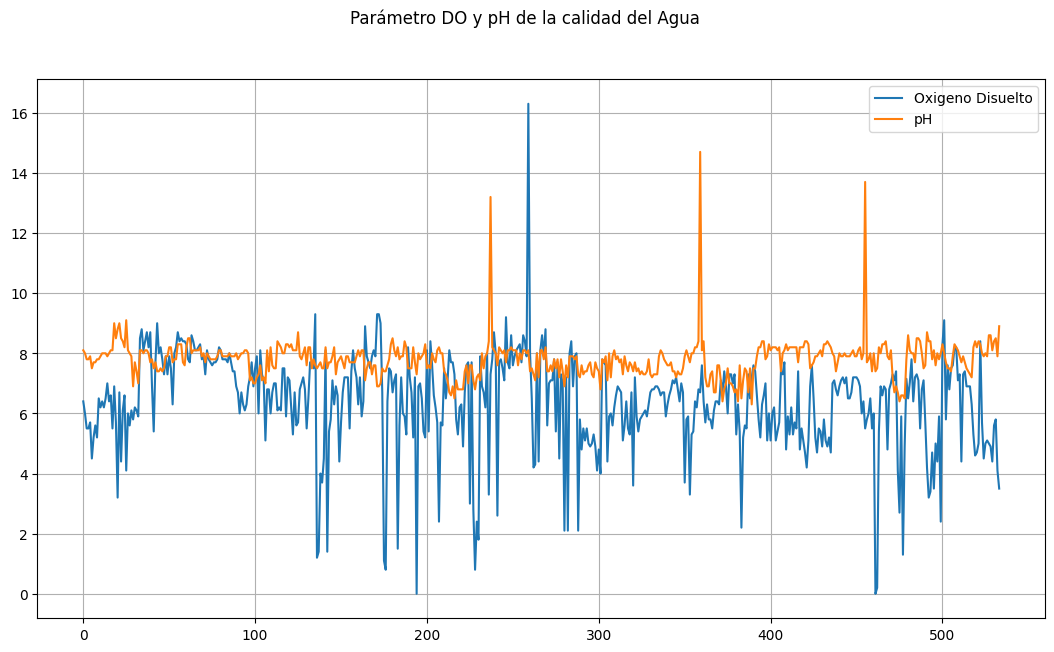

In [24]:
 import matplotlib.pyplot as plt

df01.createOrReplaceTempView("df01_sql")

do_parametro = [fila["DO"] for fila in sparkS.sql("SELECT DO FROM df01_sql").collect()]
ph_parametro = [fila["pH"] for fila in sparkS.sql("SELECT `pH` FROM df01_sql").collect()]

tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0, tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0, tam), ph_parametro, label='pH')

fig.suptitle('Parámetro DO y pH de la calidad del Agua')

legend = ax1.legend()

plt.grid()
plt.show()

* ###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos


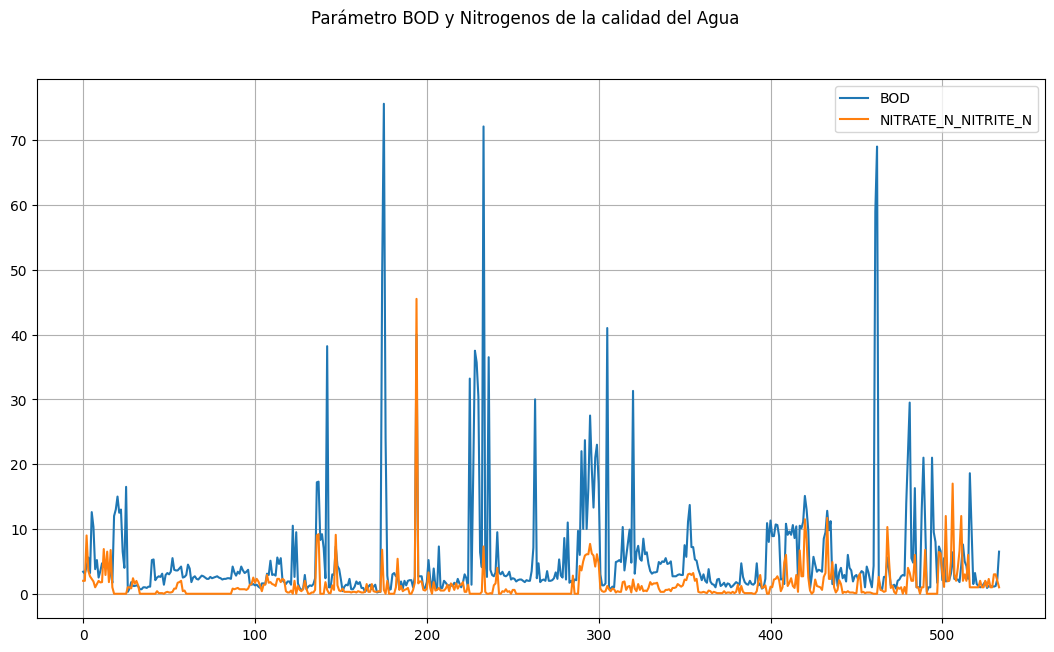

In [25]:
###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

tam = len(bod_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), bod_parametro, label='BOD')

ax1.plot(range(0,tam), nitrate_parametro, label='NITRATE_N_NITRITE_N')

fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')

legend=ax1.legend()

plt.grid()

plt.show()

* ###Grafica Los parámetros para conocer sus características: FC y Conductividad

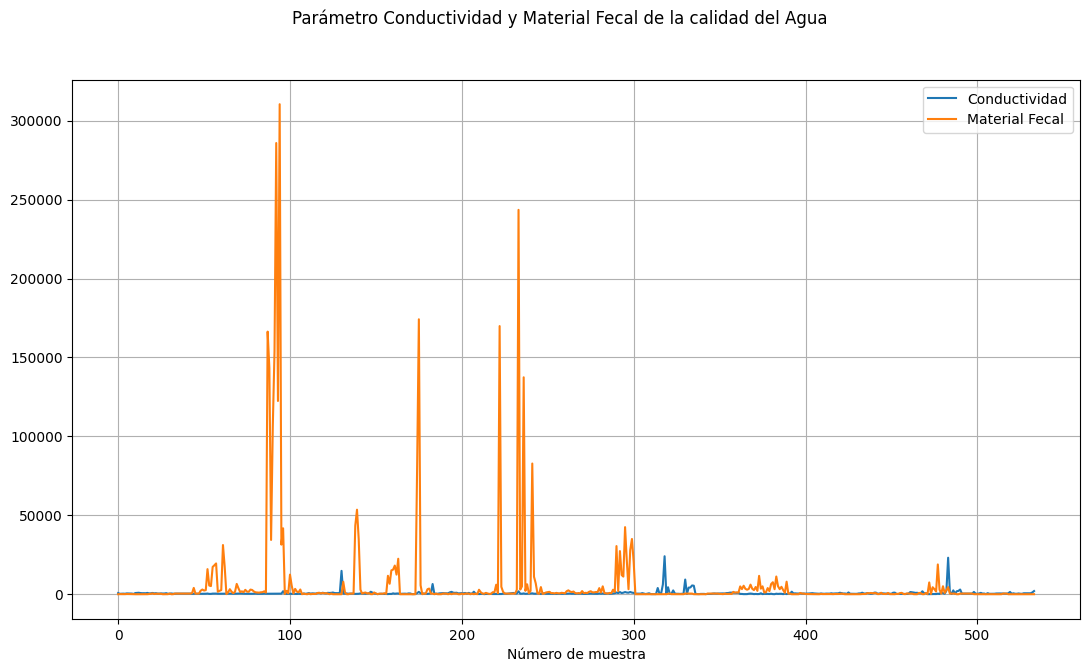

In [26]:
###Grafica Los parámetros para conocer sus características: FC y Condctividad

tam = len(conductivity_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), conductivity_parametro, label='Conductividad')

ax1.plot(range(0,tam), fecal_parametro, label='Material Fecal')

fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')

legend=ax1.legend()

plt.xlabel("Número de muestra")

plt.grid()

plt.show()

* #Función definida por el usuario para definir el rango de calidad de agua según el pH
* #Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

## 5.- Construcción del índice WQI

Para calcular el índice de calidad del agua se transforman primero las variables originales en subíndices de calidad. Cada subíndice asigna una puntuación de acuerdo con rangos establecidos para cada parámetro.

En este enfoque, valores altos del subíndice representan mejores condiciones del agua, mientras que valores bajos representan condiciones menos favorables.

In [27]:
# Función definida por el usuario para definir el rango de calidad de agua según el pH
# Se crea la columna para los rangos del parámetro

df02 = df01.withColumn(
    "qrPH",
    F.when((df01.pH >= 7) & (df01.pH <= 8.5), 100)
     .when(((df01.pH >= 6.8) & (df01.pH < 6.9)) | ((df01.pH > 8.5) & (df01.pH < 8.6)), 80)
     .when(((df01.pH >= 6.7) & (df01.pH < 6.8)) | ((df01.pH >= 8.6) & (df01.pH < 8.8)), 60)
     .when(((df01.pH >= 6.5) & (df01.pH < 6.7)) | ((df01.pH >= 8.8) & (df01.pH < 9.0)), 40)
     .otherwise(0)
)

* ### Función definida por el usuario para definir el rango de la calidad del agua según DO
* df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
  *                    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
  *                    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
  *                    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

In [28]:
# Función definida por el usuario para definir el rango de la calidad del agua según DO

df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
                   
                   when((df01.DO>=5.1) & (df01.DO<6.0), 80).
                   
                   when((df01.DO>=4.1) & (df01.DO<5.0), 60).
                   
                   when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rango de la calidad del agua según COND


In [29]:
# Función definida por el usuario para definir el rango de la calidad del agua según COND

df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).

         when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).

         when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).

         when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rango de la calidad del agua según BOD


In [30]:
# Función definida por el usuario para definir el rango de la calidad del agua según BOD

df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).

                    when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).

                    when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).

                    when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rango de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura
* df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
  *                     when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
  *                     when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
  *                     when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

In [31]:
# Función definida por el usuario para definir el rango de la calidad del agua según NITRATE_N_NITRITE_N
# 100: Agua Dulce
# 80: Agua Moderada
# 60: Agua Dura
# 40: Agua muy Dura

df02 = df02.withColumn(
    "qrNN",
    F.when((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0), 100).
      when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
      when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
      when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).
      otherwise(0)
)

* ### Función definida por el usuario para definir el rango de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura

* df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
   *                    when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
   *                    when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
   *                    when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

In [32]:
# Función definida por el usuario para definir el rango de la calidad del agua según el Material Fecal
# 100: Agua Dulce
# 80: Agua Moderada
# 60: Agua Dura
# 40: Agua muy Dura

df02 = df02.withColumn(
    "qrFecal",
    F.when(
        (df01.FECAL_COLIFORM >= 0.0) & (df01.FECAL_COLIFORM < 5.0), 100
    ).when(
        (df01.FECAL_COLIFORM >= 5.0) & (df01.FECAL_COLIFORM < 50.0), 80
    ).when(
        (df01.FECAL_COLIFORM >= 50.0) & (df01.FECAL_COLIFORM < 500.0), 60
    ).when(
        (df01.FECAL_COLIFORM >= 500.0) & (df01.FECAL_COLIFORM < 1000.0), 40
    ).otherwise(0)
)

##**El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

* #A continuación se hace una inspección en general del df02
     * df02.show(10)
* ##Nombre de Columnas
     * df02.columns

El DataFrame `df02` contiene las variables originales y los subíndices de calidad (`qrPH`, `qrDO`, `qrCOND`, `qrBOD`, `qrNN` y `qrFecal`). Estos subíndices permiten transformar variables con diferentes escalas en una escala común de calidad.

Esta transformación es necesaria para construir posteriormente el WQI mediante una suma ponderada.

In [33]:
df02.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0|          73.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0|         182.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0|         133.0| 100|  80|     0|   80| 100|     60|
|        2

In [34]:
df02.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

* Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

  Los subíndices fueron ponderados para construir el WQI. Las ponderaciones asignan diferente importancia a cada parámetro dentro del índice final. En este caso, parámetros como oxígeno disuelto y coliformes fecales tienen mayor peso dentro del cálculo, ya que representan condiciones críticas para evaluar la calidad del agua.

In [35]:
## Creación de columnas que contengan el Índice de Calidad según la referencia bibliográfica

# Se crea un nuevo objeto dataframe con las nuevas columnas de Índice de Calidad
df03 = df02.withColumn("wpH", F.round(df02.qrPH * 0.165, 3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO * 0.281, 3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND * 0.234, 3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD * 0.009, 3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN * 0.028, 3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal * 0.281, 3))

In [36]:
df03.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0|          73.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0|         182.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2

In [37]:
df03.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA



El WQI final se calculó como la suma de los subíndices ponderados. Bajo esta interpretación, valores más altos del WQI representan mejor calidad del agua, mientras que valores bajos indican condiciones de menor calidad.

In [38]:
# Calculo del Índice de Calidad del Agua

# Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR
# es que según la literatura, son muy pocos datos para que refleje un valor confiable.
# Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA
# CALIDAD DE AGUA

df04 = df03.withColumn("WQI", F.round(df03.wpH + df03.wBOD + df03.wCOND + df03.wNN + df03.wFecal + df03.wDO, 3))

df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0|          73.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0|         182.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.7

-### Intervalos de clasificación del WQI

Para este trabajo se interpreta el WQI como un índice donde valores altos representan mejor calidad del agua y valores bajos representan peor calidad.

Los intervalos usados son:

- Muy_Baja: WQI = [0, 25)
- Baja: WQI = [25, 50)
- Moderada: WQI = [50, 75)
- Buena: WQI = [75, 90)
- Excelente: WQI = [90, 100]

Esta clasificación permite mantener coherencia con el cálculo realizado, ya que los subíndices asignan mayores puntajes a mejores condiciones del agua.

In [39]:
df05 = df04.withColumn(
    "CALIDAD",
    F.when((df04.WQI >= 90) & (df04.WQI <= 100), "Excelente")
     .when((df04.WQI >= 75) & (df04.WQI < 90), "Buena")
     .when((df04.WQI >= 50) & (df04.WQI < 75), "Moderada")
     .when((df04.WQI >= 25) & (df04.WQI < 50), "Baja")
     .when((df04.WQI >= 0) & (df04.WQI < 25), "Muy_Baja")
     .otherwise("Inadecuada")
)

La distribución de categorías muestra que la mayoría de registros se concentran en la clase `Moderada`, seguida por `Baja` y `Buena`. Las clases `Excelente` y `Muy_Baja` tienen muchos menos registros, lo cual indica un posible desbalance de clases.

Este punto es importante para la etapa de modelado, especialmente si se construyen modelos de clasificación, ya que las métricas como accuracy pueden ser engañosas cuando las clases no están balanceadas.

In [40]:
df05.select("WQI", "CALIDAD").show(20)
df05.groupBy("CALIDAD").count().orderBy("CALIDAD").show()

+-----+--------+
|  WQI| CALIDAD|
+-----+--------+
|76.22|   Buena|
|74.34|Moderada|
|59.36|Moderada|
|59.36|Moderada|
|74.34|Moderada|
|53.56|Moderada|
|59.18|Moderada|
|59.36|Moderada|
|59.36|Moderada|
|84.82|   Buena|
|76.22|   Buena|
|76.22|   Buena|
|76.22|   Buena|
|76.22|   Buena|
|76.22|   Buena|
|76.22|   Buena|
|76.22|   Buena|
|65.16|Moderada|
| 48.3|    Baja|
|59.18|Moderada|
+-----+--------+
only showing top 20 rows



[Stage 64:>                                                         (0 + 1) / 1]

+---------+-----+
|  CALIDAD|count|
+---------+-----+
|     Baja|  125|
|    Buena|   70|
|Excelente|    4|
| Moderada|  321|
| Muy_Baja|   14|
+---------+-----+



In [41]:
#datos por catecoria


In [42]:
df05.groupBy("CALIDAD").count().orderBy("CALIDAD").show()

+---------+-----+
|  CALIDAD|count|
+---------+-----+
|     Baja|  125|
|    Buena|   70|
|Excelente|    4|
| Moderada|  321|
| Muy_Baja|   14|
+---------+-----+



### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

- #Impresión de nombre de regiones sobre el mapa

* colEstado = 'STATE'
* valNomnbres = df05.select(colEstado).distinct().collect()
* valNomnbres = [v[colEstado] for v in valNomnbres]

* print(valNomnbres)


In [43]:
    #Impresión de nombre de regiones sobre el mapa
    colEstado = 'STATE'
    valNomnbres = df05.select(colEstado).distinct().collect()
    valNomnbres = [v[colEstado] for v in valNomnbres]
    print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**


In [44]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [45]:
import geopandas as gpd

In [46]:
rutaMapas = "file:///Almacen/Indian_States.shp"
gpd01 = gpd.read_file(rutaMapas)
print(type(gpd01))
gpd01.columns

gpd01["st_nm"].unique()

gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                    'Daman & Diu': 'Daman Diu', 
                     'Jammu & Kashmir': 'Jammu Kashmir',
                    'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [47]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0|          73.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|   Buena|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0|         182.0| 100| 100|    40|   80| 1

### Promedio de WQI por estado

Para representar la calidad del agua en el mapa, primero se calculó el promedio del WQI por estado. Esta decisión evita tomar una sola estación como representante de todo el estado, ya que algunos estados pueden tener varias mediciones.

De esta forma, el mapa muestra una visión más general de la calidad promedio del agua por estado y no únicamente el valor de una muestra individual.

In [48]:
# Se cambia el nombre en el GeoDataFrame del mapa para que coincida con el DataFrame de calidad
gpd03 = gpd02.rename(columns={"st_nm": "STATE"})

# Se calcula el promedio del WQI por estado
df_estado = df06.groupBy("STATE").agg(
    F.round(F.avg("WQI"), 3).alias("WQI_promedio")
)

# Se pasa el resumen por estado a pandas para poder unirlo con GeoPandas
df_estado_pd = df_estado.toPandas()

# Se une el mapa con el promedio de WQI por estado
dfMAP = pd.merge(
    gpd03,
    df_estado_pd,
    how="left",
    on="STATE"
)

# Se crean coordenadas internas para poner etiquetas en el mapa
dfMAP["coords"] = dfMAP["geometry"].apply(lambda x: x.representative_point().coords[:])
dfMAP["coords"] = [coords[0] for coords in dfMAP["coords"]]

### **Se pinta el mapa inicial**

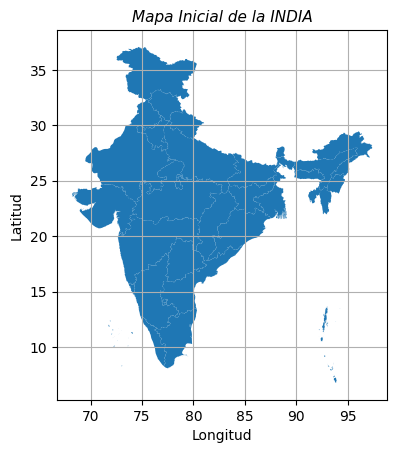

In [49]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [50]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [51]:
dfMAP.columns

Index(['STATE', 'geometry', 'WQI_promedio', 'coords'], dtype='object')

Para la visualización geográfica se calculó el promedio del WQI por estado. Esta decisión evita que un solo registro represente a todo un estado y permite comparar la calidad promedio del agua entre regiones.

In [52]:
gpd03 = gpd02.rename(columns={"st_nm": "STATE"})

df_estado = df06.groupBy("STATE").agg(
    F.round(F.avg("WQI"), 3).alias("WQI_promedio")
)

df_estado_pd = df_estado.toPandas()

dfMAP = pd.merge(
    gpd03,
    df_estado_pd,
    how="left",
    on="STATE"
)

dfMAP["coords"] = dfMAP["geometry"].apply(lambda x: x.representative_point().coords[:])
dfMAP["coords"] = [coords[0] for coords in dfMAP["coords"]]

### **Histograma de WQI por Estado**

### Análisis del WQI promedio por estado

El gráfico de barras permite comparar el WQI promedio entre los estados con mediciones disponibles. A diferencia de la visualización anterior, en esta versión cada estado aparece una sola vez, evitando duplicaciones causadas por múltiples estaciones de monitoreo.

Los estados con mayor WQI promedio presentan mejores condiciones generales de calidad del agua, mientras que los estados con menor WQI promedio requieren mayor atención en el análisis ambiental.

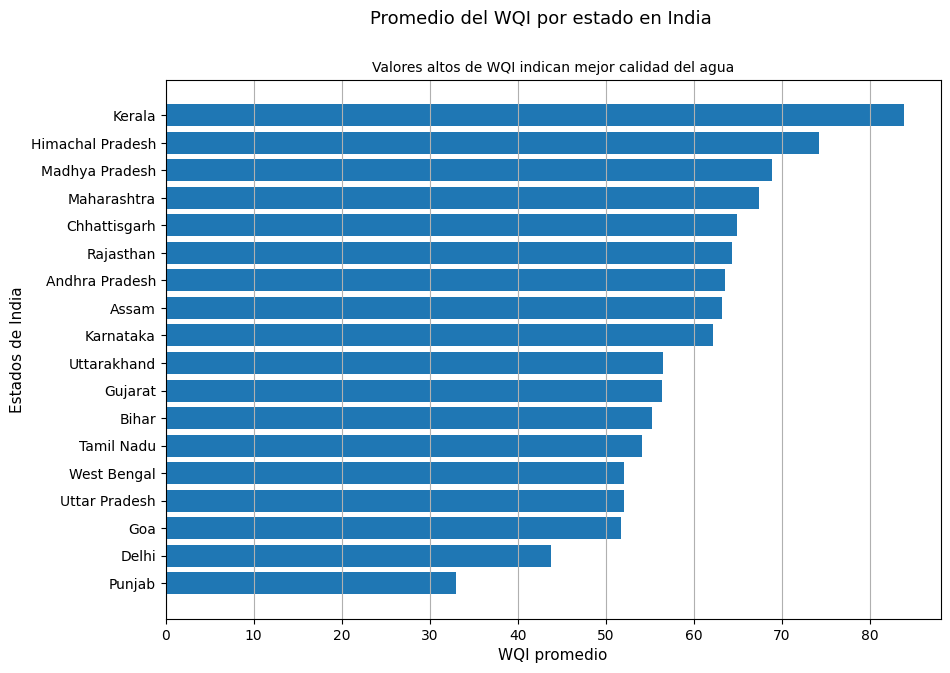

In [53]:
df_estado_pd_ordenado = df_estado_pd.sort_values("WQI_promedio", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(df_estado_pd_ordenado["STATE"], df_estado_pd_ordenado["WQI_promedio"])

plt.suptitle("Promedio del WQI por estado en India", fontsize=13)
plt.title("Valores altos de WQI indican mejor calidad del agua", fontsize=10)
plt.xlabel("WQI promedio", fontsize=11)
plt.ylabel("Estados de India", fontsize=11)
plt.grid(axis="x")
plt.show()

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

Para la construcción del modelo se utilizaron herramientas comunes en aprendizaje automático. La división de datos en entrenamiento y prueba se realizó con `train_test_split`, función de Scikit-learn utilizada para separar arreglos o matrices en subconjuntos aleatorios de entrenamiento y prueba. Además, las variables fueron estandarizadas con `StandardScaler`, que transforma los datos restando la media y dividiendo por la desviación estándar. Finalmente, el modelo fue construido con Keras, una API de alto nivel de TensorFlow para crear y entrenar modelos de aprendizaje profundo. 

## Referencias

- Scikit-learn. (2026). *train_test_split*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

- Scikit-learn. (2026). *StandardScaler*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

- TensorFlow. (2022). *Keras: API de alto nivel de TensorFlow*. TensorFlow Core. https://www.tensorflow.org/guide/keras?hl=es-419

In [54]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

### Selección de variables para el modelo de regresión

Para el modelo de regresión se utilizan como variables de entrada los parámetros originales medidos en el agua: temperatura, oxígeno disuelto, pH, conductividad, BOD, nitratos/nitritos y coliformes fecales.

La variable objetivo es el índice `WQI`. Esta elección permite que el modelo aprenda la relación entre las mediciones originales y el índice de calidad del agua, en lugar de aprender directamente a partir de los subíndices `qr*` usados para calcular el WQI.

In [55]:
# Variables predictoras originales
variables_modelo = [
    'TEMP',
    'DO',
    'pH',
    'CONDUCTIVITY',
    'BOD',
    'NITRATE_N_NITRITE_N',
    'FECAL_COLIFORM'
]

# Variable objetivo numérica
variable_objetivo = 'WQI'

dfcalidad = df06.select(variables_modelo)
dfPredecir = df06.select(variable_objetivo)

dfcalidad.show(5)
dfPredecir.show(5)

+----+---+---+------------+---+-------------------+--------------+
|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+----+---+---+------------+---+-------------------+--------------+
|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0|
|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0|
|25.8|5.5|7.8|       355.0|4.2|                9.0|          59.0|
|24.8|5.5|7.8|       371.0|5.6|               3.55|          90.0|
|25.7|5.7|7.9|       294.0|3.2|               2.69|          45.0|
+----+---+---+------------+---+-------------------+--------------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



### División de los datos

Los datos se dividen en un conjunto de entrenamiento y un conjunto de prueba. El 80% de los registros se usa para entrenar el modelo, mientras que el 20% restante se reserva para evaluar su desempeño con datos no vistos.

### Normalización de variables

Antes de entrenar la red neuronal, las variables de entrada fueron estandarizadas. Esto es necesario porque los parámetros del agua tienen escalas muy diferentes: por ejemplo, el pH se mueve alrededor de 7 u 8, mientras que la conductividad y los coliformes fecales pueden tomar valores mucho más grandes.

La normalización evita que las variables con mayor escala dominen el entrenamiento del modelo.

In [56]:
from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(
    dfcalidad.toPandas(),
    dfPredecir.toPandas(),
    test_size=0.2,
    random_state=1
)

In [57]:
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()

dataTrain_scaled = scaler_reg.fit_transform(dataTrain)
dataTest_scaled = scaler_reg.transform(dataTest)

In [58]:
import numpy as np

print("NaN en dataTrain_scaled:", np.isnan(dataTrain_scaled).sum())
print("Infinitos en dataTrain_scaled:", np.isinf(dataTrain_scaled).sum())
print("NaN en dataTest_scaled:", np.isnan(dataTest_scaled).sum())
print("Infinitos en dataTest_scaled:", np.isinf(dataTest_scaled).sum())
print("NaN en predTrain:", predTrain.isnull().sum())
print("NaN en predTest:", predTest.isnull().sum())

NaN en dataTrain_scaled: 0
Infinitos en dataTrain_scaled: 0
NaN en dataTest_scaled: 0
Infinitos en dataTest_scaled: 0
NaN en predTrain: WQI    0
dtype: int64
NaN en predTest: WQI    0
dtype: int64


In [59]:
dataTrain, dataTest, predTrain, predTest = train_test_split(
    dfcalidad.toPandas(),
    dfPredecir.toPandas(),
    test_size=0.2,
    random_state=1
)

In [60]:
from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(
    dfcalidad.toPandas(),
    dfPredecir.toPandas(),
    test_size=0.2,
    random_state=1
)

#validacion de datos nulos

In [61]:
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()

dataTrain_scaled = scaler_reg.fit_transform(dataTrain)
dataTest_scaled = scaler_reg.transform(dataTest)

### Entrenamiento del modelo Keras de regresión

El modelo de regresión se entrena usando las variables originales normalizadas como entrada y el índice `WQI` como variable objetivo. Se utiliza una red neuronal pequeña para reducir el riesgo de sobreajuste, junto con `EarlyStopping` para detener el entrenamiento si la pérdida de validación deja de mejorar.

In [62]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping

epocas = 200
lote = 32

modelo01 = Sequential([
    Input(shape=(len(variables_modelo),)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

modelo01.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mse', 'mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

modelo01.summary()

2026-04-27 22:46:29.500696: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 22:46:29.574356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 22:46:31.279703: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 22:46:31.472584: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo Keras de regresión

El modelo se entrena usando las variables originales normalizadas como entrada y el índice `WQI` como variable objetivo. Se usa `EarlyStopping` para detener el entrenamiento si la pérdida de validación deja de mejorar.

In [63]:
ejecutarK = modelo01.fit(
    dataTrain_scaled,
    predTrain,
    validation_split=0.2,
    epochs=epocas,
    batch_size=lote,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3733.4216 - mae: 59.3124 - mse: 3733.4216 - val_loss: 3881.0872 - val_mae: 60.3379 - val_mse: 3881.0872
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3744.0635 - mae: 59.5379 - mse: 3744.0635 - val_loss: 3856.8391 - val_mae: 60.1313 - val_mse: 3856.8391
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3844.7478 - mae: 60.4761 - mse: 3844.7478 - val_loss: 3829.7878 - val_mae: 59.8973 - val_mse: 3829.7878
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3593.2725 - mae: 58.2403 - mse: 3593.2725 - val_loss: 3798.6423 - val_mae: 59.6255 - val_mse: 3798.6423
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3557.7937 - mae: 57.7411 - mse: 3557.7937 - val_loss: 3761.6274 - val_mae: 59.2999 - val_mse: 3761.6274
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3645.1013 - mae: 58.5106 - mse: 3645.1013 - val_loss: 3716.1243 - val_mae: 58.8993 - val_mse: 3716.1243
Epoch 7/200
11/11 ━

In [64]:
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()

dataTrain_scaled = scaler_reg.fit_transform(dataTrain)
dataTest_scaled = scaler_reg.transform(dataTest)

In [65]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 25)
Cantidad de datos Entrenamiento: (427, 7)
Cantidad de datos Prueba: (107, 7)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


In [69]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

NameError: name 'keras' is not defined

In [ ]:
ejecutarK = modelo01.fit(
    dataTrain_scaled,
    predTrain,
    validation_split=0.2,
    epochs=epocas,
    batch_size=lote,
    callbacks=[early_stop],
    verbose=1
)

### Evaluación del modelo Keras de regresión

El modelo de regresión se evalúa sobre el conjunto de prueba usando MAE, MSE, RMSE y R². Estas métricas permiten medir qué tan cerca están las predicciones del WQI real.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

predicciones_wqi = modelo01.predict(dataTest_scaled).flatten()
valores_reales_wqi = predTest.values.flatten()

mae = mean_absolute_error(valores_reales_wqi, predicciones_wqi)
mse = mean_squared_error(valores_reales_wqi, predicciones_wqi)
rmse = np.sqrt(mse)
r2 = r2_score(valores_reales_wqi, predicciones_wqi)

print("Evaluación del modelo Keras de regresión")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

### Análisis de la evaluación del modelo de regresión

El modelo Keras de regresión obtuvo un MAE de 7.5481 y un RMSE de 9.5740. Esto significa que, en promedio, las predicciones del modelo se alejan aproximadamente entre 7 y 10 puntos del valor real del WQI. Teniendo en cuenta que el WQI se interpreta en una escala aproximada de 0 a 100, el error es moderado y permite considerar que el modelo logra capturar parte del comportamiento general del índice.

El valor de R² fue 0.5243, lo que indica que el modelo logra explicar cerca del 52.43% de la variabilidad del WQI en el conjunto de prueba. Aunque este resultado no representa un ajuste perfecto, sí muestra que las variables originales del agua aportan información útil para predecir el índice.

Sin embargo, el desempeño también evidencia que existen limitaciones. El WQI fue construido a partir de rangos discretos y ponderaciones, mientras que el modelo intenta aproximarlo como una variable continua. Además, algunas variables como `FECAL_COLIFORM` y `CONDUCTIVITY` presentan valores extremos, lo cual puede dificultar el aprendizaje del modelo.

En general, el modelo de regresión funciona como una primera aproximación para estimar el WQI, pero se recomienda complementar este análisis con un modelo de clasificación que prediga directamente la categoría `CALIDAD`.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(ejecutarK.history['loss'], label='Pérdida entrenamiento')
plt.plot(ejecutarK.history['val_loss'], label='Pérdida validación')

plt.title("Curva de pérdida del modelo Keras de regresión")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio")
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la curva de pérdida

La curva de pérdida permite observar cómo evoluciona el error del modelo durante el entrenamiento. La línea de entrenamiento muestra el comportamiento del modelo con los datos usados para aprender, mientras que la línea de validación muestra su desempeño con datos separados del entrenamiento.

Si ambas curvas disminuyen y se mantienen cercanas, el modelo está aprendiendo de forma estable. Si la pérdida de entrenamiento baja mucho pero la de validación aumenta, puede existir sobreajuste.